# Quick-look for simulations

This notebook can be used to have a quicklook at the that product for the simulations.

In [221]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [222]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim libraries
from platosim.lightcurve import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

---
## Single mode
---

In [223]:
path = '/lhome/nicholas/software/workdir/cs-binary/output'
filename = f"{path}/000000001/000000001_Ncam1.1_Q1.hdf5"

# path = '/lhome/nicholas/software/workdir/cs-planet/output/'
# filename = f"{path}/000000001/000000001_Ncam1.5_Q1.hdf5"

# path = '/lhome/nicholas/software/workdir/cs-exomoon/output/'
# filename = f"{path}/000000001/000000001_Ncam1.1_Q8.hdf5"

# Load a single mission quarter light curve
lc = LightCurve(filename, mode="single")

In [224]:
# Fetch overview table
ds = lc.star()
ds

ID                     1
PIC        2894734000017
ra             87.912089
dec           -57.246682
mag              10.1768
group                  1
camera                 1
quarter                1
ccd                    1
xCCD          397.464653
yCCD         1438.541691
rOA            13.015347
xFP            -8.454364
yFP             56.58625
ncon                   1
SPR             0.006272
Name: 0, dtype: object

<IPython.core.display.Javascript object>


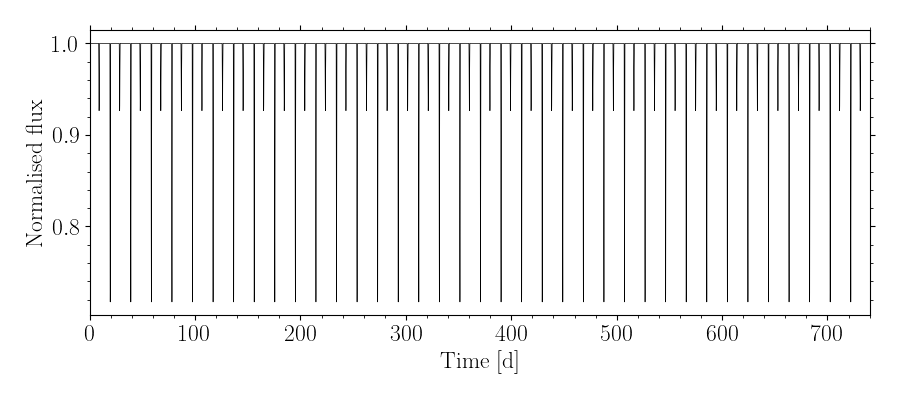

In [225]:
# Show in the injected variability
dv = lc.varsource()

fig, ax = plt.subplots(1, 1, figsize=(9,4))
ax.plot(dv.time/86400, dv.flux, 'k-', lw=0.5)
ax.set_xlabel('Time [d]')
ax.set_ylabel('Normalised flux')
ax.set_xlim(dv.time.min()/86400, dv.time.max()/86400)
plt.tight_layout();

<IPython.core.display.Javascript object>


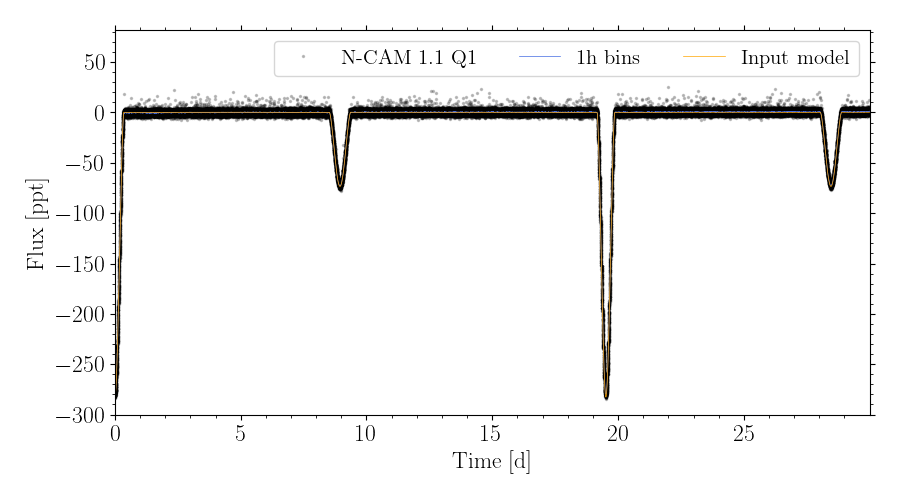

In [244]:
# Show a quarter light curve
lc.plot(flux_unit='ppt', median_filter=1, input_model=True, figsize=(9,5));

### *Test post-processing*

<IPython.core.display.Javascript object>


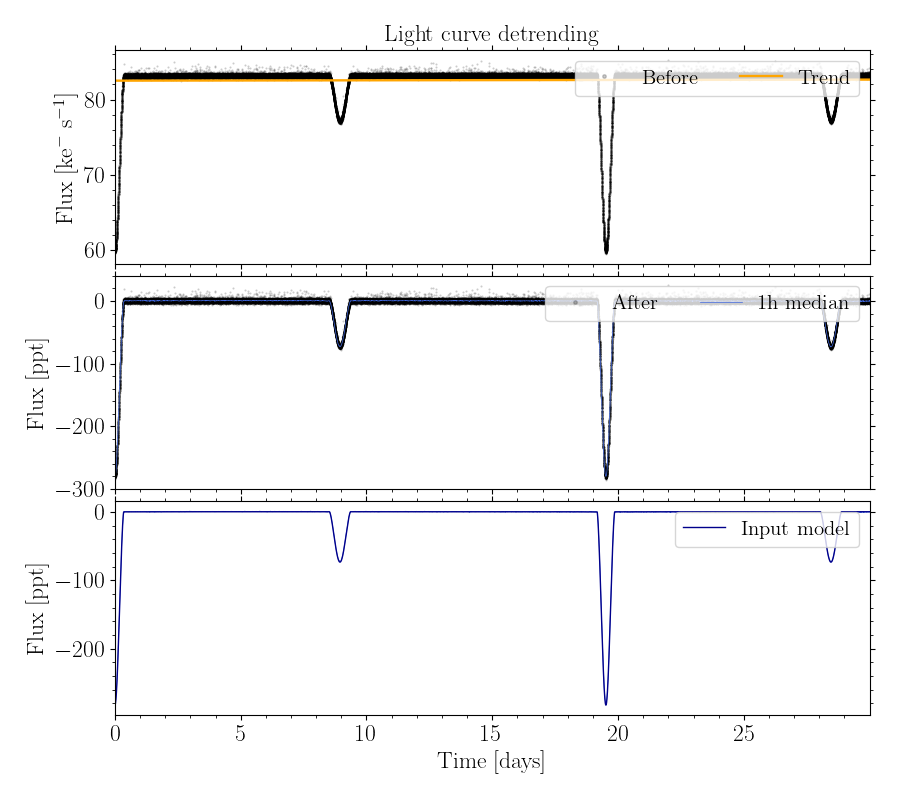

In [228]:
# Detrend light curve (segment=True if you want it to be done per mask update)
df = lc.detrend(model='poly', degree=1, segments=True, plot=True)

<IPython.core.display.Javascript object>


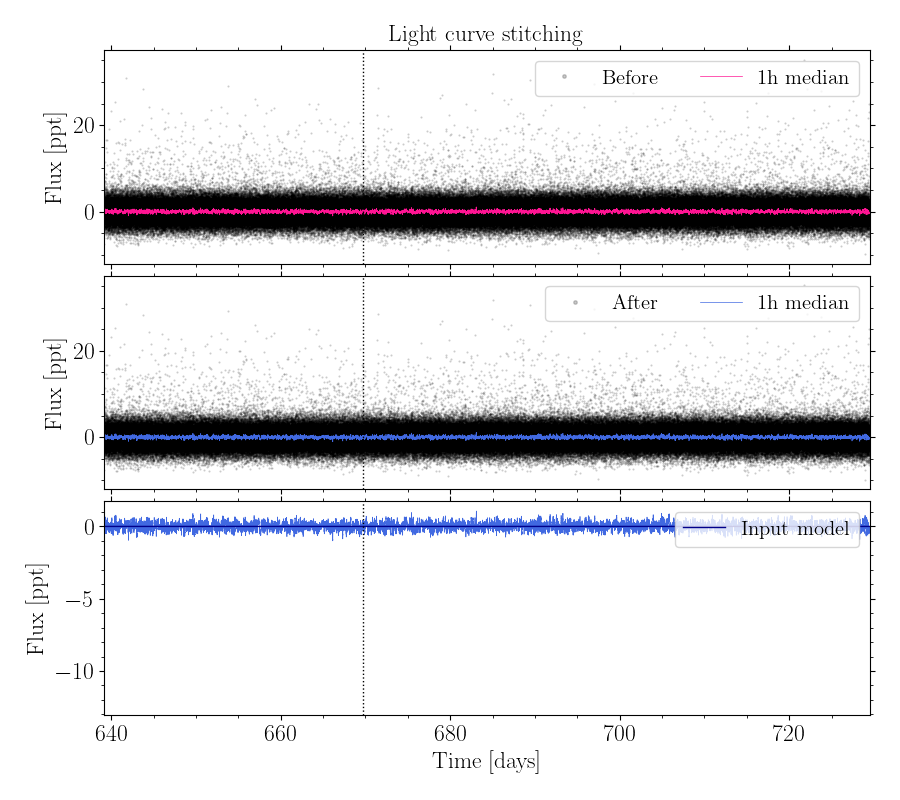

In [196]:
# Stitch the segments (only needed if detrending leaves big jumps)
df = lc.stitch(column='flux_detrend', method='median', gapsize=0.1, segment=5, plot=True)

<IPython.core.display.Javascript object>


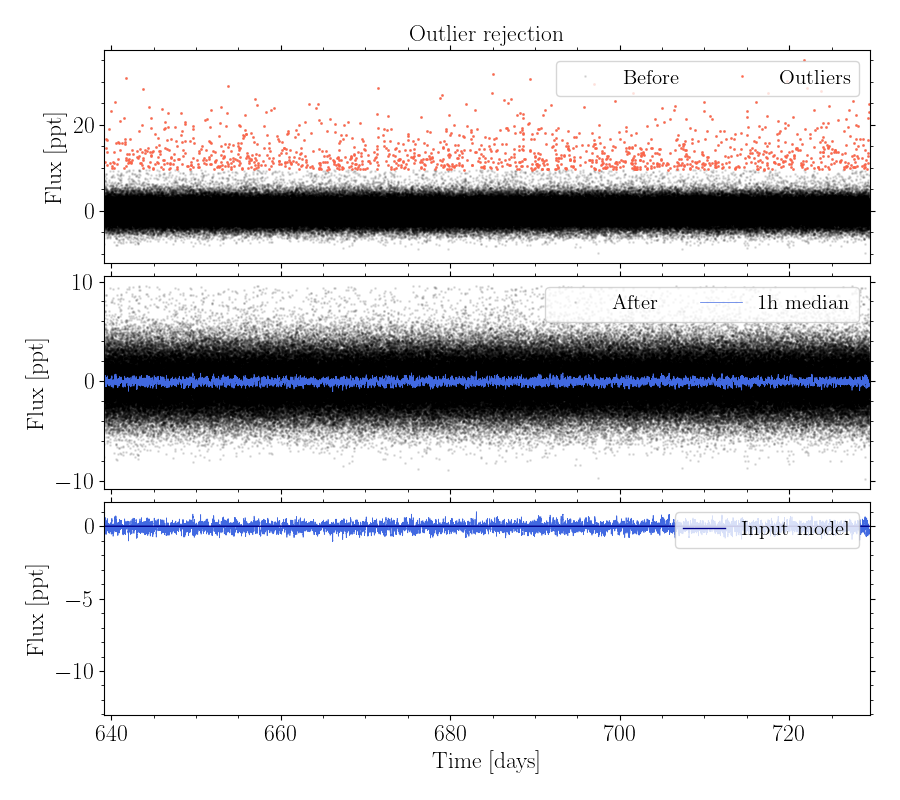

In [197]:
# Remove outliers (due to photon noise and cosmic ray hits)
df = lc.clip(column='flux_stitch', magnitude=ds.mag, flux_unit='ppt', plot=True)

---
## Multi mode
---

In [206]:
# path = '/lhome/nicholas/software/workdir/cs-binary/tests/test1/output'

# path = '/lhome/nicholas/software/workdir/cs-planet/tests/test2/output/000000001'

# path = '/lhome/nicholas/software/workdir/cs-exomoon/test/test0/output'
path = '/lhome/nicholas/software/workdir/cs-exomoon/test/test1_wotan/output/000000001'

# In multi mode we parse the entire directory of files
lcs = LightCurve(path, mode="multi")

In [207]:
lcs.unpack()

### *Use multi-mode as single-mode*

In [208]:
# Fetch files in folder
filenames = lcs.files(suffix='ftr')
filenames[:3]

['/lhome/nicholas/software/workdir/cs-exomoon/test/test1_wotan/output/000000001/000000001_Ncam1.1_Q1.ftr',
 '/lhome/nicholas/software/workdir/cs-exomoon/test/test1_wotan/output/000000001/000000001_Ncam1.1_Q2.ftr',
 '/lhome/nicholas/software/workdir/cs-exomoon/test/test1_wotan/output/000000001/000000001_Ncam1.1_Q3.ftr']

In [209]:
# Again one can fetch the first light curve for this star
lc = LightCurve(filenames[0])
lc.data().head()

,time,flux
0,18.75,1.004051
1,43.75,1.000137
2,68.75,1.001568
3,93.75,0.998064
4,118.75,1.000290


### *Simulation statistics*

The `.table` files each contain a small overview of the specific simulation. It is much handier to have a single file to search information from, hence, we can merge to one single overview table as follows. It possible to remove the redundant `.table` files during the process using `clean=True`:

In [210]:
df = lcs.stat_sim_table(ofile=f'{path}/lc_final_000000001.tab', clean=True)
df.head()

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.83


,ID,PIC,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,1,2707228000089,93.000747,-46.153593,10.3988,1,1,1,4,1814.610378,2470.933830,11.635389,38.003191,33.962987,1,0.010232
1,1,2707228000089,93.000747,-46.153593,10.3988,1,1,2,4,1015.721385,2715.308631,8.930164,33.604445,19.582985,1,0.007684
2,1,2707228000089,93.000747,-46.153593,10.3988,1,1,3,4,1231.465472,3499.698542,7.025095,19.485426,23.466378,1,0.006881
3,1,2707228000089,93.000747,-46.153593,10.3988,1,1,4,4,2027.360888,3267.760341,10.211670,23.660314,37.792496,1,0.010526
4,1,2707228000089,93.000747,-46.153593,10.3988,1,1,5,4,1814.837452,2470.982379,11.635849,38.002317,33.967074,1,0.010858


### *View simulations*

<IPython.core.display.Javascript object>


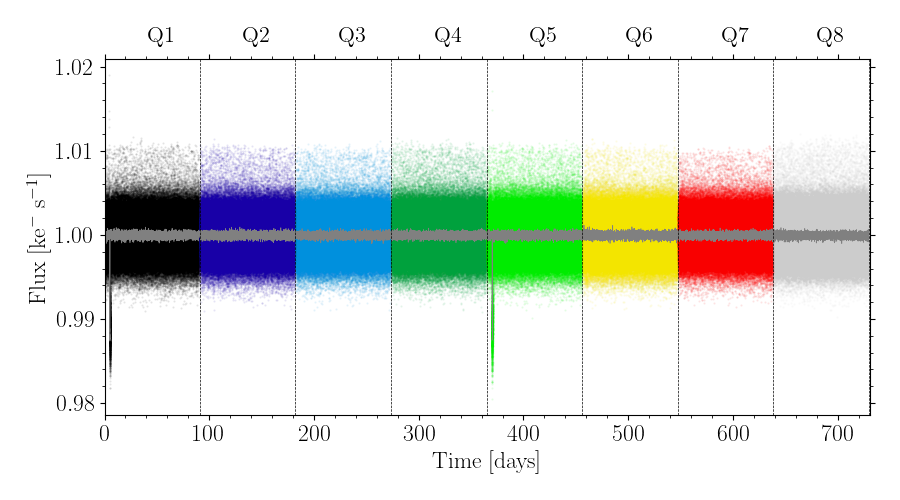

In [211]:
fig, ax = lcs.plot_multi(suffix='ftr', group=1, camera=4, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5))

In [212]:
lc = lcs.merge(suffix='ftr', binsize=1, flux_group_mean=True, flux_offset=True, 
               ofile=f'{path}/lc_final_000000001.ftr')

Merging light curves:


100%|██████████████████████████████████████████████████| 192/192 [00:30<00:00,  


Sorting data after timings
Averaging data from same camera group
Binning data per 1h
Corrrecting flux offset of -81.48341181613006 ppm
Done!


<IPython.core.display.Javascript object>


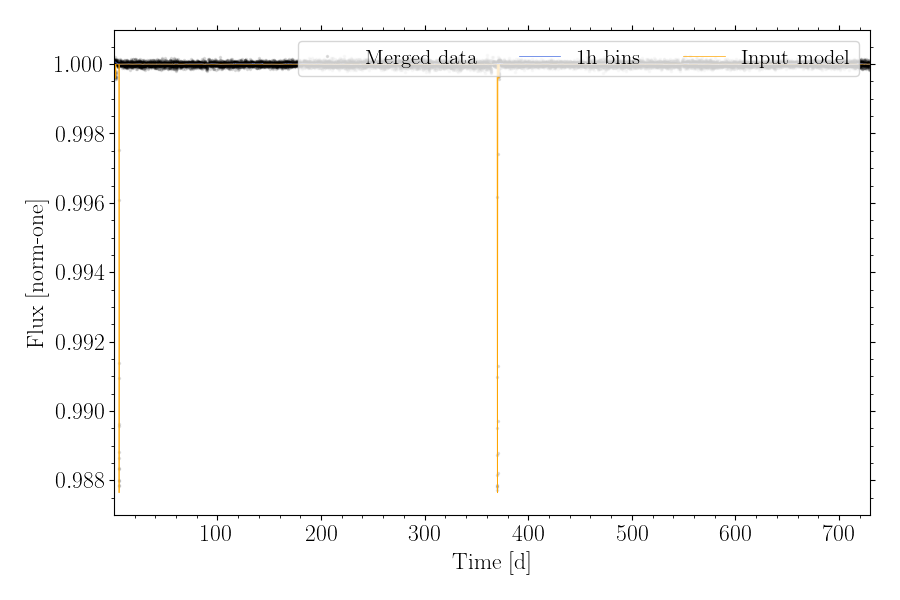

/lhome/nicholas/software/workdir/cs-exomoon/test/test1_wotan/varsource/varsource_000000001.txt


In [214]:
lc.plot(input_model=True, flux_unit='norm', median_filter=1, alpha=0.1, figsize=(9,6));

---
## Test Wotan detrending
---

In [148]:
path = '/lhome/nicholas/software/workdir/cs-planet/output/'
filename = f"{path}/000000001/000000001_Ncam1.5_Q1.hdf5"
# filename = f"{path}/000000001/000000001_Ncam2.2_Q1.hdf5"

<IPython.core.display.Javascript object>


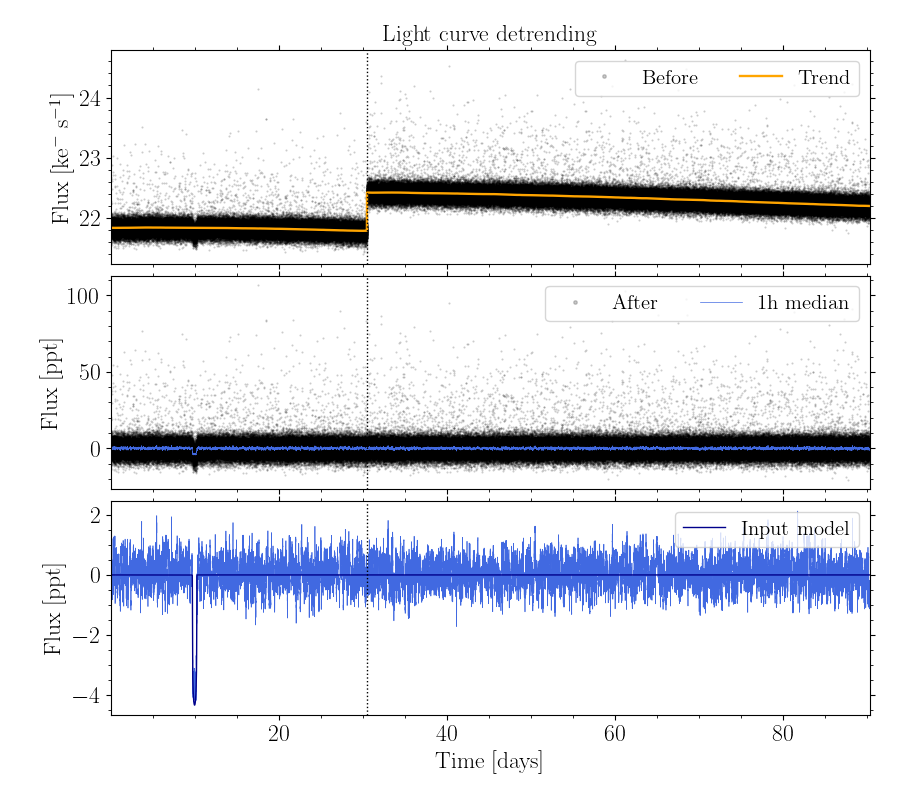

In [149]:
lc = LightCurve(filename, mode="single")
lc.detrend(model='wotan', replace=True, plot=True);